In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import json
import os
from itertools import product

(c)

In [2]:
features = ["PT1", "PT2", "P1", "P2", "TotalPT", "VertexChisq", "Isolation", "MASS"]

#load data
signal = pd.read_csv("data/signal_Bs2MuMu.txt", sep=r"\s+", header=None, names=features)
background = pd.read_csv("data/background_combinatorial.txt", sep=r"\s+", header=None, names=features)
signal = signal.apply(pd.to_numeric, errors="coerce").dropna().reset_index(drop=True)
background = background.apply(pd.to_numeric, errors="coerce").dropna().reset_index(drop=True)

#load fisher scores computed in features.ipynb
fisher_df = pd.read_csv("fisher_scores.csv")

#take top 3 excluding MASS - we need the mass distribution unbiased for the fit later
top3_features = fisher_df.loc[fisher_df["Feature"] != "MASS", "Feature"].head(3).tolist()
print("top three features (excluding MASS):", top3_features)

top three features (excluding MASS): ['VertexChisq', 'Isolation', 'P2']


We scan threshold candidates from percentiles of the combined distribution, then refine around the best found threshold.

In [3]:
#get candidate thresholds from percentiles to cover the full range
def get_thresholds(sig_vals, bkg_vals, n_points=15):
    all_vals = np.concatenate([sig_vals, bkg_vals])
    qs = np.linspace(2, 98, n_points)
    return np.unique(np.percentile(all_vals, qs))

#refine around the coarse best threshold
def refine_thresholds(sig_vals, bkg_vals, best_t, width_fraction=0.08, n_points=25):
    all_vals = np.concatenate([sig_vals, bkg_vals])
    vmin, vmax = all_vals.min(), all_vals.max()
    vrange = vmax - vmin
    low  = max(vmin, best_t - width_fraction * vrange)
    high = min(vmax, best_t + width_fraction * vrange)
    return np.unique(np.linspace(low, high, n_points))

def compute_metrics(sig_mask, bkg_mask):
    tp = int(sig_mask.sum())
    fn = int((~sig_mask).sum())
    fp = int(bkg_mask.sum())
    tn = int((~bkg_mask).sum())
    accuracy          = (tp + tn) / (len(sig_mask) + len(bkg_mask))
    signal_efficiency = tp / (tp + fn)
    background_efficiency = fp / (fp + tn)
    return dict(TP=tp, FN=fn, FP=fp, TN=tn,
                accuracy=accuracy,
                signal_efficiency=signal_efficiency,
                background_efficiency=background_efficiency,
                background_rejection=1 - background_efficiency)

#search over all combinations of direction and threshold for all three features
def search_cuts(signal_df, background_df, chosen_features, threshold_dict):
    pre_sig, pre_bkg = {}, {}
    for feat in chosen_features:
        x_sig = signal_df[feat].to_numpy()
        x_bkg = background_df[feat].to_numpy()
        ts = threshold_dict[feat]
        pre_sig[feat] = {">": [x_sig > t for t in ts], "<": [x_sig < t for t in ts]}
        pre_bkg[feat] = {">": [x_bkg > t for t in ts], "<": [x_bkg < t for t in ts]}

    f1, f2, f3 = chosen_features
    t1s = threshold_dict[f1]
    t2s = threshold_dict[f2]
    t3s = threshold_dict[f3]

    best_acc, best_cuts = 0.0, None

    for d1, d2, d3 in product([">", "<"], repeat=3):
        for i in range(len(t1s)):
            s1 = pre_sig[f1][d1][i]
            b1 = pre_bkg[f1][d1][i]
            for j in range(len(t2s)):
                s12 = s1 & pre_sig[f2][d2][j]
                b12 = b1 & pre_bkg[f2][d2][j]
                for k in range(len(t3s)):
                    s123 = s12 & pre_sig[f3][d3][k]
                    b123 = b12 & pre_bkg[f3][d3][k]
                    acc = (s123.sum() + (~b123).sum()) / (len(s123) + len(b123))
                    if acc > best_acc:
                        best_acc = acc
                        best_cuts = {
                            f1: (d1, float(t1s[i])),
                            f2: (d2, float(t2s[j])),
                            f3: (d3, float(t3s[k])),
                        }
    return best_cuts, best_acc

In [4]:
#coarse pass over percentile grid
coarse_thresholds = {
    f: get_thresholds(signal[f].to_numpy(), background[f].to_numpy())
    for f in top3_features
}
best_cuts, acc_coarse = search_cuts(signal, background, top3_features, coarse_thresholds)
print(f"coarse best accuracy: {acc_coarse:.4f}")

#refine around the best threshold for each feature
refined_thresholds = {
    f: refine_thresholds(signal[f].to_numpy(), background[f].to_numpy(), best_cuts[f][1])
    for f in top3_features
}
best_cuts, acc_final = search_cuts(signal, background, top3_features, refined_thresholds)

#apply the final cuts and compute full metrics
def apply_cuts(df, cut_dict):
    mask = np.ones(len(df), dtype=bool)
    for feat, (direction, threshold) in cut_dict.items():
        if direction == ">":
            mask &= df[feat].to_numpy() > threshold
        else:
            mask &= df[feat].to_numpy() < threshold
    return mask

sig_mask = apply_cuts(signal, best_cuts)
bkg_mask = apply_cuts(background, best_cuts)
m = compute_metrics(sig_mask, bkg_mask)

print("\noptimal rectangular cut:")
for f, (d, t) in best_cuts.items():
    print(f"  {f} {d} {t:.4f}")
print(f"\naccuracy              = {m['accuracy']:.4f}")
print(f"signal efficiency     = {m['signal_efficiency']:.4f}")
print(f"background efficiency = {m['background_efficiency']:.4f}")
print(f"background rejection  = {m['background_rejection']:.4f}")
print(f"\nTP={m['TP']}, FN={m['FN']}, FP={m['FP']}, TN={m['TN']}")

coarse best accuracy: 0.8244

optimal rectangular cut:
  VertexChisq < 11.1911
  Isolation < 0.3096
  P2 > 0.0002

accuracy              = 0.7500
signal efficiency     = 0.7865
background efficiency = 0.2865
background rejection  = 0.7135

TP=7865, FN=2135, FP=2865, TN=7135


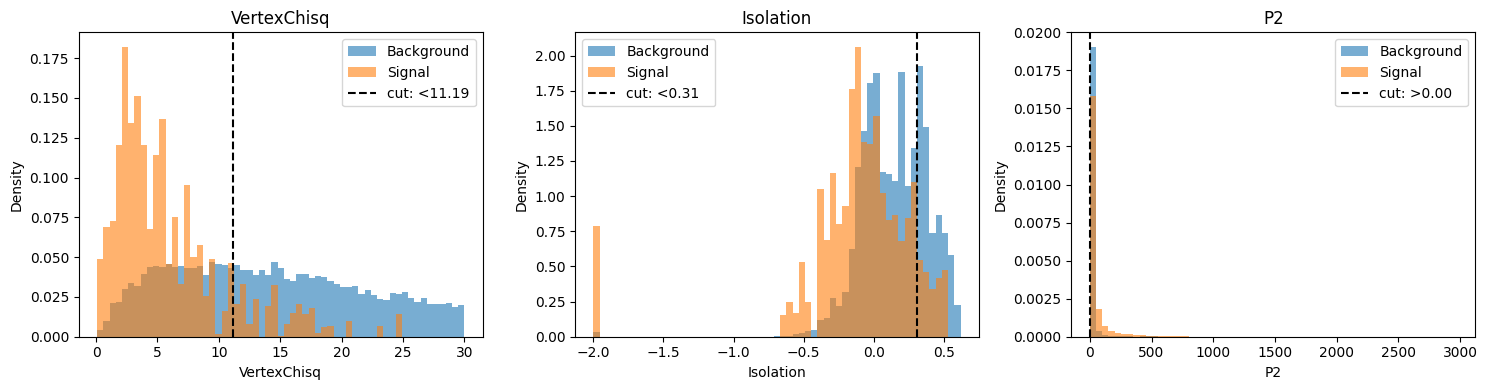

In [ ]:
#plot the distributions with the cut threshold marked for each feature
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, f in zip(axes, top3_features):
    all_vals = np.concatenate([signal[f].to_numpy(), background[f].to_numpy()])
    bins = np.linspace(all_vals.min(), all_vals.max(), 60)
    ax.hist(background[f], bins=bins, alpha=0.6, density=True, label="Background")
    ax.hist(signal[f],     bins=bins, alpha=0.6, density=True, label="Signal")
    d, thr = best_cuts[f]
    ax.axvline(thr, color="black", linestyle="--", label=f"cut: {d}{thr:.2f}")
    ax.set_title(f)
    ax.set_xlabel(f)
    ax.set_ylabel("Density")
    ax.legend()

plt.tight_layout()
plt.savefig("plots/rectangular_cuts.png", dpi=150, bbox_inches="tight")
plt.show()

In [6]:
#save cut parameters and accuracy for comparison in bdt.ipynb
output = {"cuts": {f: list(v) for f, v in best_cuts.items()}, "accuracy": acc_final}
with open("cut_params.json", "w") as fh:
    json.dump(output, fh, indent=2)
print("saved cut parameters to cut_params.json")

saved cut parameters to cut_params.json
